# **03 — MARKET BASKET ANALYSIS (SKILLS CO-OCCURRENCE)**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter
import re
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

In [9]:
df = pd.read_csv("cleaned_dataset.csv")
print(f"Data dimuat: {df.shape}")

Data dimuat: (1465, 22)


## 1. Ekstraksi Kamus Kata Kunci Skills

In [10]:
SKILLS_EXTENDED = [
    # Programming languages
    'python', 'java', 'javascript', 'php', 'kotlin', 'swift',
    'typescript', 'golang', 'ruby', 'c++', 'c#', 'scala',
    # Web & Framework
    'react', 'vue', 'angular', 'laravel', 'django', 'node',
    'spring', 'flask', 'express',
    # Data & AI
    'sql', 'mysql', 'postgresql', 'mongodb', 'excel',
    'machine learning', 'deep learning', 'tensorflow', 'pytorch',
    'data analysis', 'tableau', 'power bi', 'spark', 'hadoop',
    # Cloud & DevOps
    'aws', 'gcp', 'azure', 'docker', 'kubernetes', 'linux', 'git',
    # Mobile
    'android', 'flutter', 'ios',
    # Design
    'figma', 'ui/ux', 'photoshop', 'illustrator',
    # Business
    'seo', 'marketing', 'accounting', 'finance', 'excel',
    'project management', 'agile', 'scrum',
    # Domain
    'backend', 'frontend', 'fullstack', 'devops',
    'data science', 'data engineer', 'business analyst',
    'software engineer', 'network', 'cybersecurity',
    'ai developer', 'ml engineer',
]

def extract_all_skills(row):
    """Gabung job_title dan job_requirements, lalu ekstrak skills"""
    text = f"{row.get('job_title', '')} {row.get('job_requirements', '')}".lower()
    found = set()
    for skill in SKILLS_EXTENDED:
        if skill in text:
            found.add(skill)
    return list(found) if found else []

df['all_skills'] = df.apply(extract_all_skills, axis=1)

df_skills = df[df['all_skills'].apply(len) >= 2].copy()
print(f"\nBaris dengan ≥2 skill: {len(df_skills)} dari {len(df)}")

all_skills_flat = [s for skills in df_skills['all_skills'] for s in skills]
skill_counts = Counter(all_skills_flat)
top_skills = skill_counts.most_common(20)
print("\n=== TOP 20 SKILLS ===")
for skill, count in top_skills:
    pct = count / len(df_skills) * 100
    print(f"  {skill:25s} : {count:4d} ({pct:.1f}%)")


Baris dengan ≥2 skill: 72 dari 1465

=== TOP 20 SKILLS ===
  finance                   :   24 (33.3%)
  git                       :   24 (33.3%)
  marketing                 :   22 (30.6%)
  accounting                :   21 (29.2%)
  excel                     :   17 (23.6%)
  java                      :    8 (11.1%)
  sql                       :    8 (11.1%)
  azure                     :    7 (9.7%)
  c#                        :    5 (6.9%)
  python                    :    5 (6.9%)
  android                   :    5 (6.9%)
  aws                       :    5 (6.9%)
  php                       :    4 (5.6%)
  react                     :    3 (4.2%)
  seo                       :    3 (4.2%)
  network                   :    3 (4.2%)
  docker                    :    3 (4.2%)
  gcp                       :    3 (4.2%)
  ios                       :    3 (4.2%)
  mysql                     :    2 (2.8%)


## 2. Perhitungan Aturan Asosiasi (Support, Confidence, & Lift Kustom)

In [11]:
n_transactions = len(df_skills)

pair_counts = Counter()
single_counts = Counter()

for skills in df_skills['all_skills']:
    unique_skills = list(set(skills))
    for s in unique_skills:
        single_counts[s] += 1
    for pair in combinations(sorted(unique_skills), 2):
        pair_counts[pair] += 1

MIN_SUPPORT = 0.03

rules = []
for (a, b), count in pair_counts.items():
    support = count / n_transactions
    if support < MIN_SUPPORT:
        continue

    conf_ab = count / single_counts[a]
    conf_ba = count / single_counts[b]

    sup_a = single_counts[a] / n_transactions
    sup_b = single_counts[b] / n_transactions
    lift   = support / (sup_a * sup_b)

    rules.append({
        'antecedent': a, 'consequent': b,
        'support': round(support, 4),
        'confidence': round(conf_ab, 4),
        'lift': round(lift, 4),
        'count': count
    })
    rules.append({
        'antecedent': b, 'consequent': a,
        'support': round(support, 4),
        'confidence': round(conf_ba, 4),
        'lift': round(lift, 4),
        'count': count
    })

rules_df = pd.DataFrame(rules)
rules_df = rules_df.sort_values('lift', ascending=False).drop_duplicates()
print(f"\nTotal rules ditemukan: {len(rules_df)}")

strong_rules = rules_df[
    (rules_df['confidence'] >= 0.4) &
    (rules_df['lift'] >= 1.2)
].sort_values('lift', ascending=False).head(30)

print("\n=== TOP 15 ASSOCIATION RULES (berdasarkan Lift) ===")
print(f"{'Antecedent':<22} → {'Consequent':<22} | Sup   | Conf  | Lift")
print("-" * 75)
for _, row in strong_rules.head(15).iterrows():
    print(f"  {row['antecedent']:<20} → {row['consequent']:<20} | {row['support']:.3f} | {row['confidence']:.3f} | {row['lift']:.3f}")


Total rules ditemukan: 58

=== TOP 15 ASSOCIATION RULES (berdasarkan Lift) ===
Antecedent             → Consequent             | Sup   | Conf  | Lift
---------------------------------------------------------------------------
  gcp                  → aws                  | 0.042 | 1.000 | 14.400
  aws                  → gcp                  | 0.042 | 0.600 | 14.400
  python               → docker               | 0.042 | 0.600 | 14.400
  docker               → python               | 0.042 | 1.000 | 14.400
  ios                  → android              | 0.042 | 1.000 | 14.400
  android              → ios                  | 0.042 | 0.600 | 14.400
  gcp                  → python               | 0.042 | 1.000 | 14.400
  python               → gcp                  | 0.042 | 0.600 | 14.400
  aws                  → docker               | 0.042 | 0.600 | 14.400
  docker               → aws                  | 0.042 | 1.000 | 14.400
  python               → aws                  | 0.056 | 0.800 |

## 3. Visualisasi Pola Hubungan Aturan Asosiasi

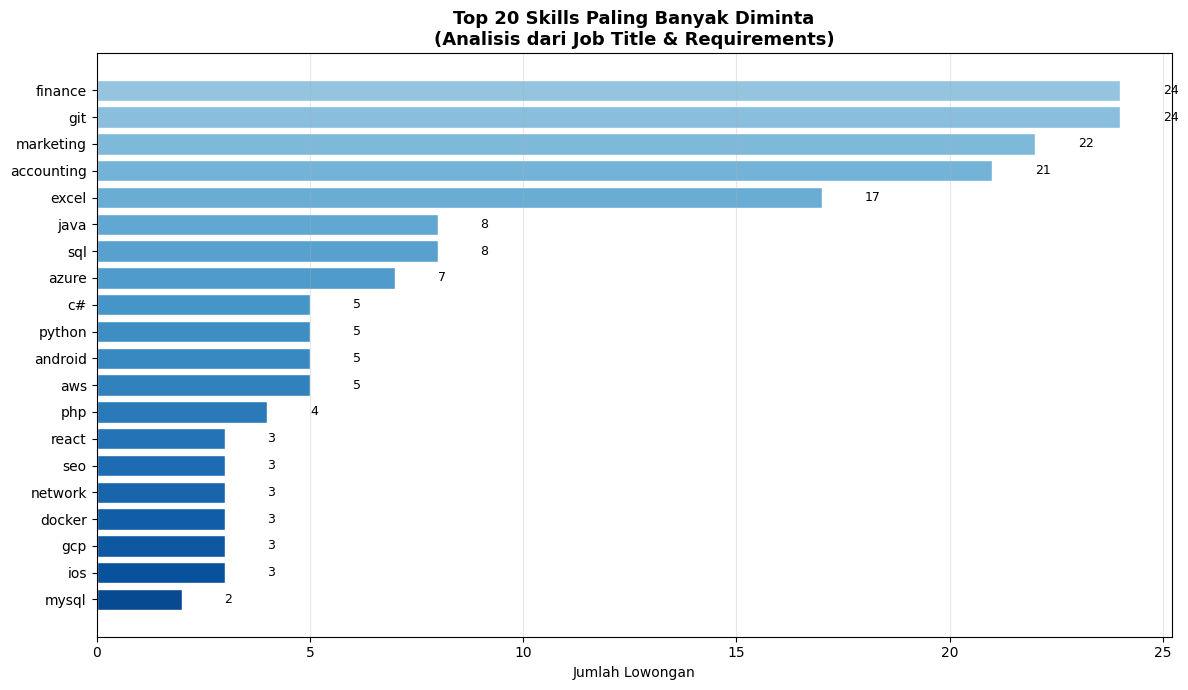

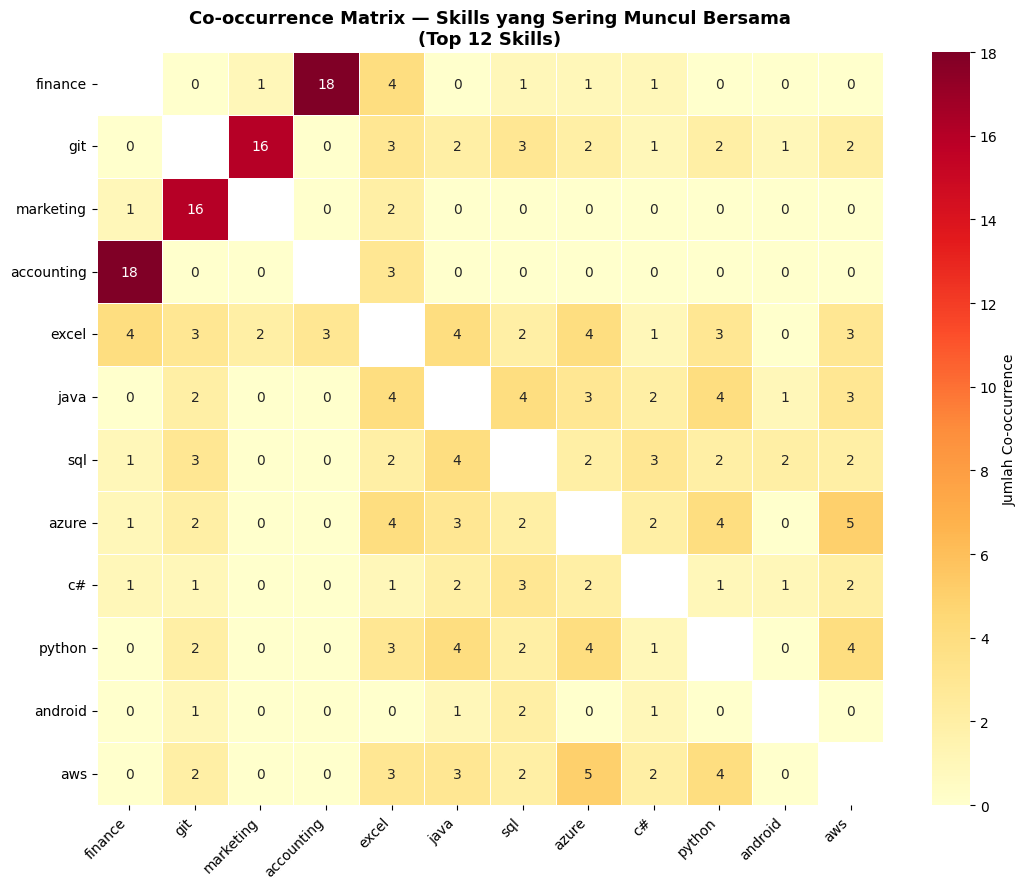

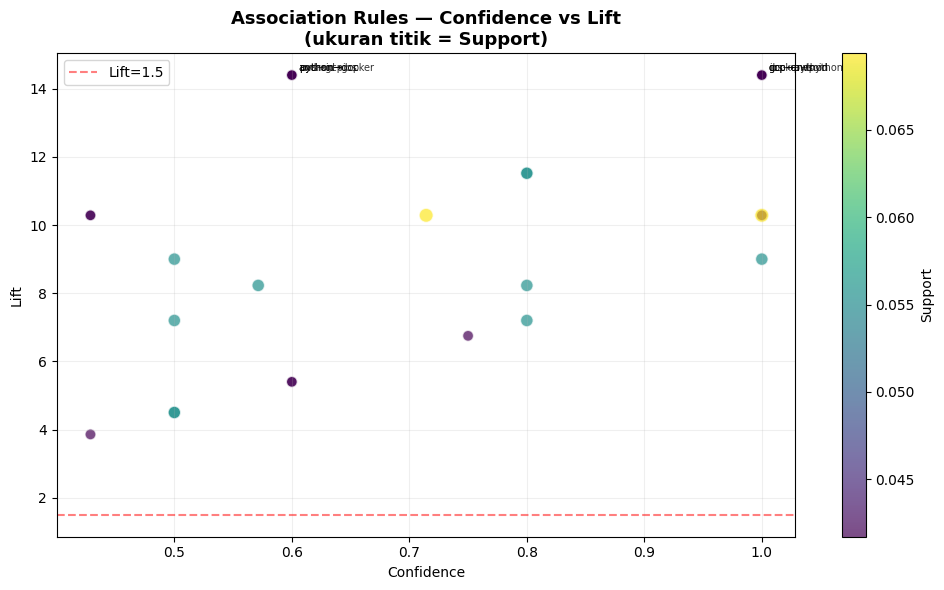

In [12]:
skills_series = pd.Series(dict(top_skills))
colors_bar = plt.cm.Blues(np.linspace(0.4, 0.9, len(skills_series)))[::-1]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(skills_series.index[::-1], skills_series.values[::-1],
               color=colors_bar, edgecolor='white')
ax.set_title("Top 20 Skills Paling Banyak Diminta\n(Analisis dari Job Title & Requirements)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Jumlah Lowongan")
for bar, val in zip(bars, skills_series.values[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


top12 = [s for s, _ in skill_counts.most_common(12)]
cooc_matrix = pd.DataFrame(0, index=top12, columns=top12)

for skills in df_skills['all_skills']:
    skill_set = set(skills) & set(top12)
    for a, b in combinations(skill_set, 2):
        cooc_matrix.loc[a, b] += 1
        cooc_matrix.loc[b, a] += 1

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.eye(len(top12), dtype=bool)
sns.heatmap(cooc_matrix, annot=True, fmt='d', cmap='YlOrRd',
            mask=mask, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Jumlah Co-occurrence'})
ax.set_title("Co-occurrence Matrix — Skills yang Sering Muncul Bersama\n(Top 12 Skills)",
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


if len(strong_rules) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    sc = ax.scatter(strong_rules['confidence'], strong_rules['lift'],
                    c=strong_rules['support'], cmap='viridis',
                    s=strong_rules['support'] * 1500, alpha=0.7, edgecolors='white')

    for _, row in strong_rules.head(8).iterrows():
        ax.annotate(f"{row['antecedent']}→{row['consequent']}",
                    (row['confidence'], row['lift']),
                    textcoords='offset points', xytext=(5, 3), fontsize=7, alpha=0.8)

    plt.colorbar(sc, ax=ax, label='Support')
    ax.axhline(y=1.5, color='red', linestyle='--', alpha=0.5, label='Lift=1.5')
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Lift")
    ax.set_title("Association Rules — Confidence vs Lift\n(ukuran titik = Support)",
                 fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

## Menyimpan Hasil Evaluasi Akhir

In [13]:
rules_df.to_csv("association_rules.csv", index=False)
print("File 'association_rules.csv' berhasil disimpan!")

print("\n=== STATISTIK RINGKAS INTERPRETASI ===")
print(f"Total keahlian unik yang terdeteksi : {len(skill_counts)} jenis")
print(f"Aturan asosiasi dengan Lift > 1.5   : {len(rules_df[rules_df['lift'] > 1.5])} aturan")

File 'association_rules.csv' berhasil disimpan!

=== STATISTIK RINGKAS INTERPRETASI ===
Total keahlian unik yang terdeteksi : 44 jenis
Aturan asosiasi dengan Lift > 1.5   : 50 aturan


In [14]:
rules_df.to_csv("association_rules.csv", index=False)
print("\nAssociation rules berhasil disimpan")

print("\n=== INSIGHT UTAMA ===")
print(f"Total skills terdeteksi : {len(skill_counts)} jenis")
print(f"Total transactions      : {n_transactions}")
print(f"Total rules (min sup 3%): {len(rules_df)}")
print(f"Strong rules (conf≥0.4) : {len(strong_rules)}")
print(f"\nSkill paling populer    : {top_skills[0][0]} ({top_skills[0][1]} lowongan)")
print(f"Rule lift tertinggi     : {strong_rules.iloc[0]['antecedent']} → {strong_rules.iloc[0]['consequent']} (lift={strong_rules.iloc[0]['lift']})")


Association rules berhasil disimpan

=== INSIGHT UTAMA ===
Total skills terdeteksi : 44 jenis
Total transactions      : 72
Total rules (min sup 3%): 58
Strong rules (conf≥0.4) : 30

Skill paling populer    : finance (24 lowongan)
Rule lift tertinggi     : gcp → aws (lift=14.4)
